   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
   --------------- ------------------------ 5.0/12.8 MB 23.1 MB/s eta 0:00:01
   ----------------------------------- ---- 11.3/12.8 MB 28.2 MB/s eta 0:00:01
   ---------------------------------------- 12.8/12.8 MB 25.1 MB/s  0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 23.6 MB/s  0:00:00
   ---------------------------------------- 0.0/114.5 MB ? eta -:--:--
   -- ------------------------------------- 7.3/114.5 MB 34.9 MB/s eta 0:00:04
   ----- ---------------------------------- 15.2/114.5 MB 36.8 MB/s eta 0:00:03
   ------- -------------------------------- 22.0/114.5 MB 35.7 MB/s eta 0:00:03
   ---------- ----------------------------- 29.4/114.5 MB 35.8 MB/s eta 0:00:03
   ------------ --------------------------- 36.7/114.5 MB 35.3 MB/s eta 0:00:03
   --------------- ------------------------ 44.6/114.5 MB 35.9 MB/s eta 0:00:02
   -

In [2]:
import os
# why is this here? This is disabling some tensorflow warning I get in some of my environments that 
# annoy me (look ugly and untidy really)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import keras
from keras.datasets import fashion_mnist
from keras import regularizers
from keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D, Flatten
from keras.utils import to_categorical
from keras.models import Model

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

import numpy
import scipy.io

from sklearn.manifold import TSNE

In [3]:
import medmnist
from medmnist import OrganCMNIST

# Make sure all three splits are loaded!
train_dataset = OrganCMNIST(split='train', download=True)
val_dataset = OrganCMNIST(split='val', download=True)
test_dataset = OrganCMNIST(split='test', download=True)

Using downloaded and verified file: /Users/jessie.bowness/.medmnist/organcmnist.npz
Using downloaded and verified file: /Users/jessie.bowness/.medmnist/organcmnist.npz
Using downloaded and verified file: /Users/jessie.bowness/.medmnist/organcmnist.npz


In [12]:
# 1. Extract the raw image arrays
x_train_raw = train_dataset.imgs
x_val_raw = val_dataset.imgs
x_test_raw = test_dataset.imgs

# 2. NORMALIZE: Convert to float32 and divide by 255 to squash between 0 and 1
x_train_normalized = x_train_raw.astype('float32') / 255.0
x_val_normalized = x_val_raw.astype('float32') / 255.0
x_test_normalized = x_test_raw.astype('float32') / 255.0

# Data Preprocessing 

In [13]:
import numpy as np

# Safely add the channel dimension (the '1') to the very end (axis=-1)
x_train_reshaped = np.expand_dims(x_train_normalized, axis=-1)
x_val_reshaped = np.expand_dims(x_val_normalized, axis=-1)

# Just to be 100% sure, print the shape before training!
# It should print: (23583, 28, 28, 1)
print("New training shape:", x_train_reshaped.shape)

New training shape: (12975, 28, 28, 1)


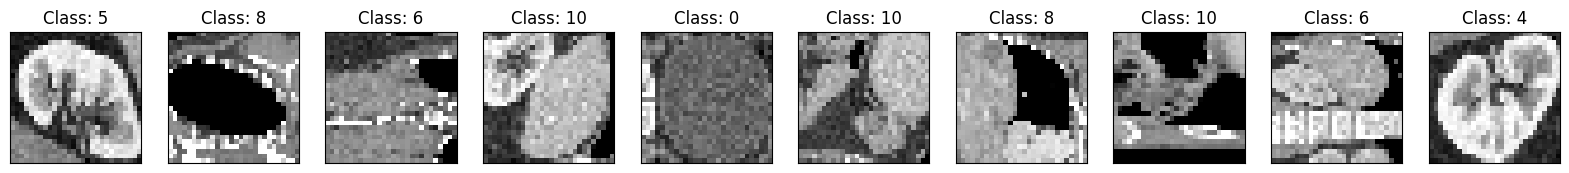

In [6]:

# 2. Extract the raw images and labels
# .imgs gets the array of images, .labels gets the array of class numbers
images = train_dataset.imgs
labels = train_dataset.labels

# 3. Set up a Matplotlib figure
n = 10 # Number of images to show
plt.figure(figsize=(20, 4))

for i in range(n):
    # Create a subplot for each image in a 1x10 grid
    ax = plt.subplot(1, n, i + 1)
    
    # Plot the image (it's already 28x28, so no reshaping needed)
    plt.imshow(images[i], cmap='gray')
    
    # Add the label as the title so you know what organ class it is
    # The [0] is just because the labels are formatted as arrays like [3]
    plt.title(f"Class: {labels[i][0]}")
    
    # Hide the axes for a cleaner look
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

# Display the plot
plt.show()

# Building the Network

In [8]:
from tensorflow import keras
from tensorflow.keras import layers, Model

# ==========================================
# 1. THE SHARED INPUT
# ==========================================
# Explicitly set to 28x28 grayscale
inputs = keras.Input(shape=(28, 28, 1), name='image_input')

# ==========================================
# 2. THE SHARED ENCODER (The Bottleneck)
# ==========================================
# Math: Starts at 28x28
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
x = layers.MaxPooling2D((2, 2), padding='same')(x) 
# Math: Now 14x14

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x) 
# Math: Now 7x7 (This is our shared bottleneck!)

# ==========================================
# BRANCH A: THE CLASSIFIER 
# ==========================================
# Flatten the 7x7 bottleneck into a 1D list
c = layers.Flatten()(encoded)
c = layers.Dense(64, activation='relu')(c)

# Output Layer A: 11 neurons for the 11 organ classes
# We name it 'class_output' to help Keras track it later
class_output = layers.Dense(11, activation='softmax', name='class_output')(c)

# ==========================================
# BRANCH B: THE DECODER (Reconstruction)
# ==========================================
# Math: Starts at 7x7 (from the encoded bottleneck)
d = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
d = layers.UpSampling2D((2, 2))(d) 
# Math: Scaled up to 14x14

d = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(d)
d = layers.UpSampling2D((2, 2))(d) 
# Math: Scaled up to exactly 28x28!

# Output Layer B: 1 channel, sigmoid activation to output pixel values
# We name it 'decoder_output'
decoder_output = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same', name='decoder_output')(d)

# ==========================================
# 3. BUILD THE FINAL MULTI-TASK MODEL
# ==========================================
# Notice the list of TWO outputs matching our two branches
multitask_cnn = Model(inputs=inputs, outputs=[class_output, decoder_output])

# Print the summary to verify the shapes
multitask_cnn.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 28, 28,    │        160 │ image_input[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 14, 14,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 14, 14,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 7, 7, 32)  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 7, 7, 32)  │      9,248 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 14, 14,    │          0 │ conv2d_2[0][0]    │
│ (UpSampling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1568)      │          0 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 14, 14,    │      4,624 │ up_sampling2d[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │    100,416 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 28, 28,    │          0 │ conv2d_3[0][0]    │
│ (UpSampling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_output        │ (None, 11)        │        715 │ dense[0][0]       │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_output      │ (None, 28, 28, 1) │        145 │ up_sampling2d_1[… │
│ (Conv2D)            │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 119,948 (468.55 KB)

 Trainable params: 119,948 (468.55 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
multitask_cnn.compile(
    optimizer='adam',
    loss={
        'class_output': 'sparse_categorical_crossentropy', # For the labels
        'decoder_output': 'mse'                            # For the pixels
    },
    metrics={
        'class_output': 'accuracy'                         # Only track accuracy on the labels
    }
)

In [17]:
# 1. Extract the labels for your classification targets
y_train_labels = train_dataset.labels
y_val_labels = val_dataset.labels

# 2. Reshape your normalized images to include the (..., 28, 28, 1) channel
x_train_reshaped = x_train_normalized.reshape(-1, 28, 28, 1)
x_val_reshaped = x_val_normalized.reshape(-1, 28, 28, 1)

history = multitask_cnn.fit(
    x=x_train_reshaped,                                 
    y=[y_train_labels, x_train_reshaped],               # [Target Labels, Target Images]
    batch_size=32,
    epochs=100,
    validation_data=(
        x_val_reshaped,                                 
        [y_val_labels, x_val_reshaped]                  
    ),
    verbose=True
)

Epoch 1/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - class_output_accuracy: 0.4496 - class_output_loss: 1.6328 - decoder_output_loss: 0.0369 - loss: 3.4792 - val_class_output_accuracy: 0.6463 - val_class_output_loss: 1.2968 - val_decoder_output_loss: 0.0323 - val_loss: 2.9141
Epoch 2/100
 86/406 ━━━━━━━━━━━━━━━━━━━━ 18s 59ms/step - class_output_accuracy: 0.6290 - class_output_loss: 1.1778 - decoder_output_loss: 0.0251 - loss: 2.4353

KeyboardInterrupt: 

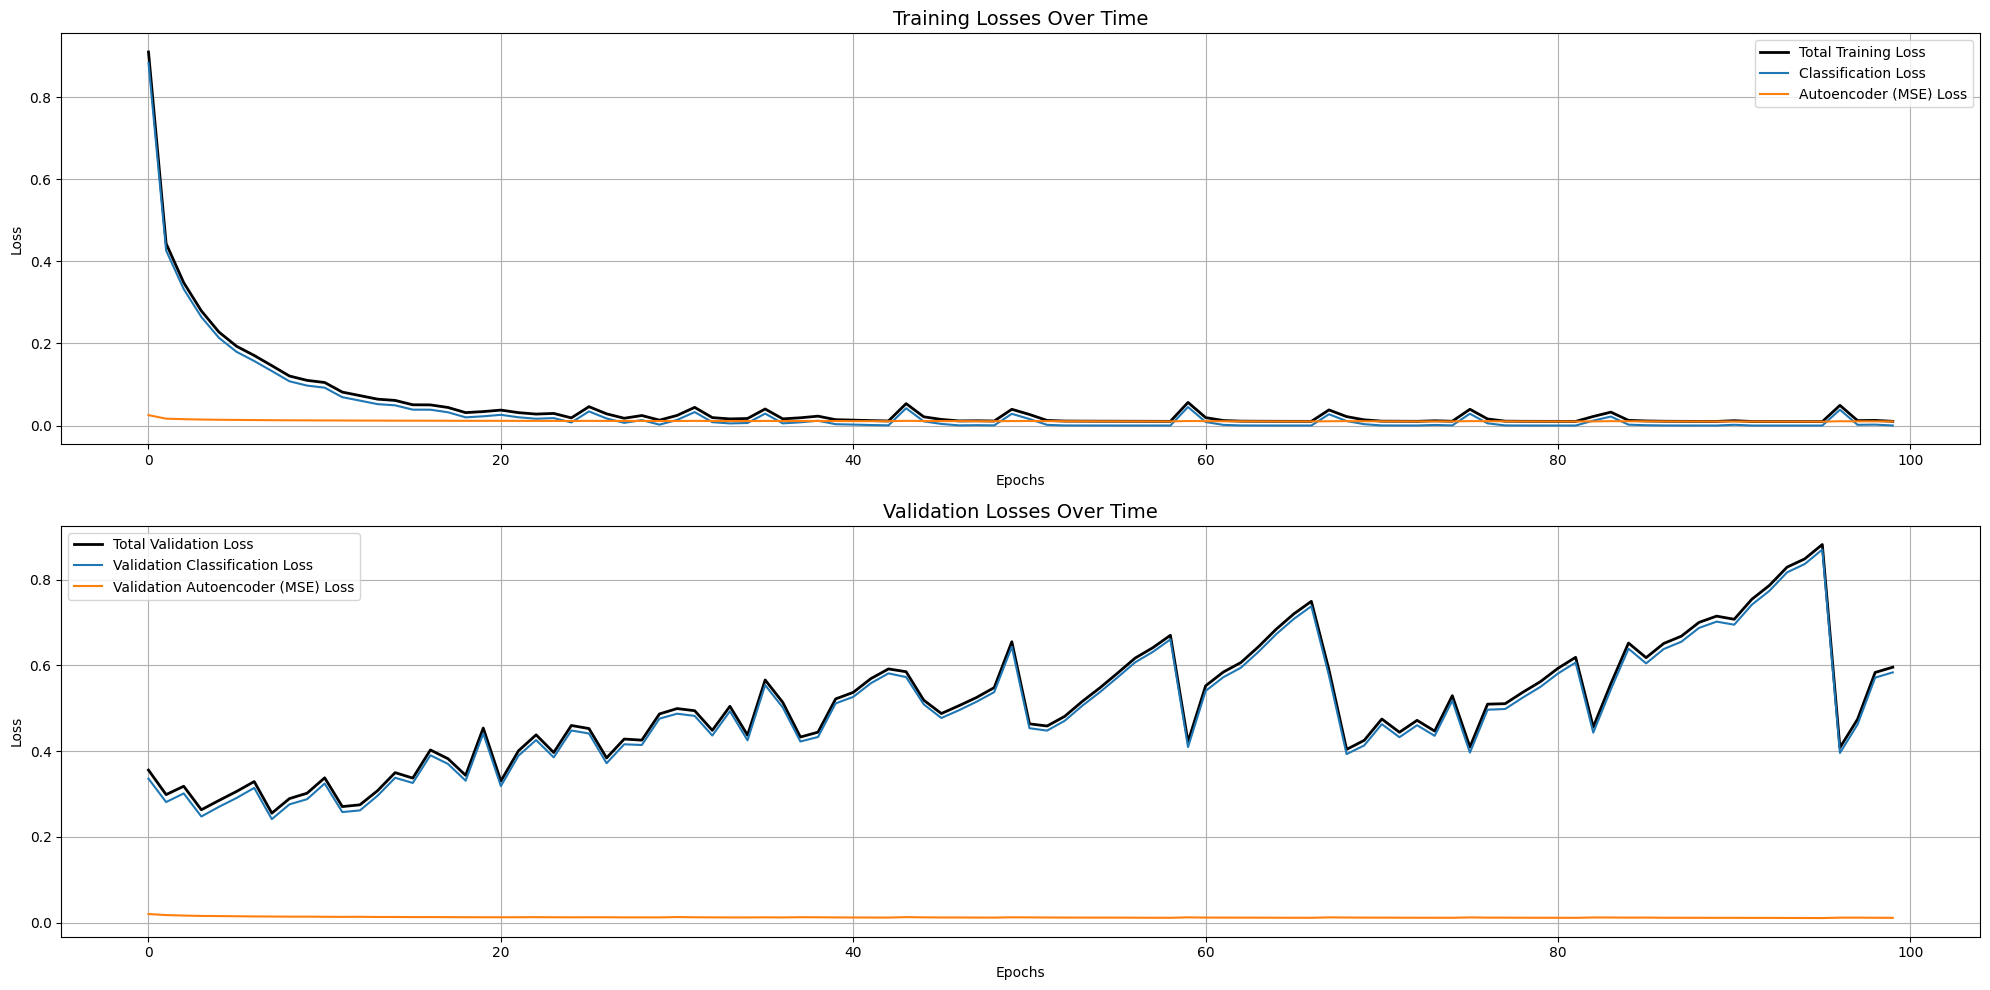

In [12]:
# Create the figure canvas
fig = plt.figure(figsize=[20, 10])

# ==========================================
# TOP GRAPH: Training Losses
# ==========================================
ax = fig.add_subplot(2, 1, 1)

# Plot the combined total loss
ax.plot(history.history['loss'], label='Total Training Loss', color='black', linewidth=2)

# Plot the individual branch losses
# Note the updated keys: <layer_name>_loss
ax.plot(history.history['class_output_loss'], label='Classification Loss')
ax.plot(history.history['decoder_output_loss'], label='Autoencoder (MSE) Loss')

ax.set_title('Training Losses Over Time', fontsize=14)
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True)

# ==========================================
# BOTTOM GRAPH: Validation Losses
# ==========================================
ax = fig.add_subplot(2, 1, 2)

# Plot the combined total validation loss
ax.plot(history.history['val_loss'], label='Total Validation Loss', color='black', linewidth=2)

# Plot the individual branch validation losses
ax.plot(history.history['val_class_output_loss'], label='Validation Classification Loss')
ax.plot(history.history['val_decoder_output_loss'], label='Validation Autoencoder (MSE) Loss')

ax.set_title('Validation Losses Over Time', fontsize=14)
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True)

# Ensure titles and labels don't overlap
plt.tight_layout()
plt.show()

Classic Exammple of overfitting by the classification branch
The Math Problem: Cross-Entropy loss (classification) naturally produces much larger numbers than Mean Squared Error loss (reconstruction).The Result: Because Keras simply adds them together ($Total = Class + MSE$), the Classification Loss is acting like a loud boss yelling through a megaphone, while the Autoencoder is whispering.The Failure Mode: The network essentially ignores the reconstruction task entirely. Because it ignores the autoencoder, it loses all of the "regularization" benefits we talked about earlier. Without that physical grounding, the classification branch runs wild and overfits.

In [15]:
multitask_cnn.compile(
    optimizer='adam',
    loss={
        'class_output': 'sparse_categorical_crossentropy', 
        'decoder_output': 'mse'                            
    },
    # Force the model to pay 10x more attention to the drawing task
    loss_weights={
        'class_output': 1.0, 
        'decoder_output': 10.0  
    },
    metrics={'class_output': 'accuracy'}
)

In [16]:
history = multitask_cnn.fit(
    x=x_train_reshaped,                                 
    y=[y_train_labels, x_train_reshaped],               # [Target Labels, Target Images]
    batch_size=32,
    epochs=100,
    validation_data=(
        x_val_reshaped,                                 
        [y_val_labels, x_val_reshaped]                  
    ),
    verbose=True
)

Epoch 1/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - class_output_accuracy: 0.9977 - class_output_loss: 0.0059 - decoder_output_loss: 0.0100 - loss: 0.1056 - val_class_output_accuracy: 0.9544 - val_class_output_loss: 0.4913 - val_decoder_output_loss: 0.0107 - val_loss: 0.5987
Epoch 2/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - class_output_accuracy: 0.9985 - class_output_loss: 0.0044 - decoder_output_loss: 0.0097 - loss: 0.1018 - val_class_output_accuracy: 0.9557 - val_class_output_loss: 0.4743 - val_decoder_output_loss: 0.0109 - val_loss: 0.5827
Epoch 3/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - class_output_accuracy: 0.9974 - class_output_loss: 0.0104 - decoder_output_loss: 0.0099 - loss: 0.1093 - val_class_output_accuracy: 0.9515 - val_class_output_loss: 0.5040 - val_decoder_output_loss: 0.0107 - val_loss: 0.6114
Epoch 4/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - class_output_accuracy: 0.9999 - class_output_loss: 7.2594e-04 - decoder_output_loss: 0.0096 - loss: 

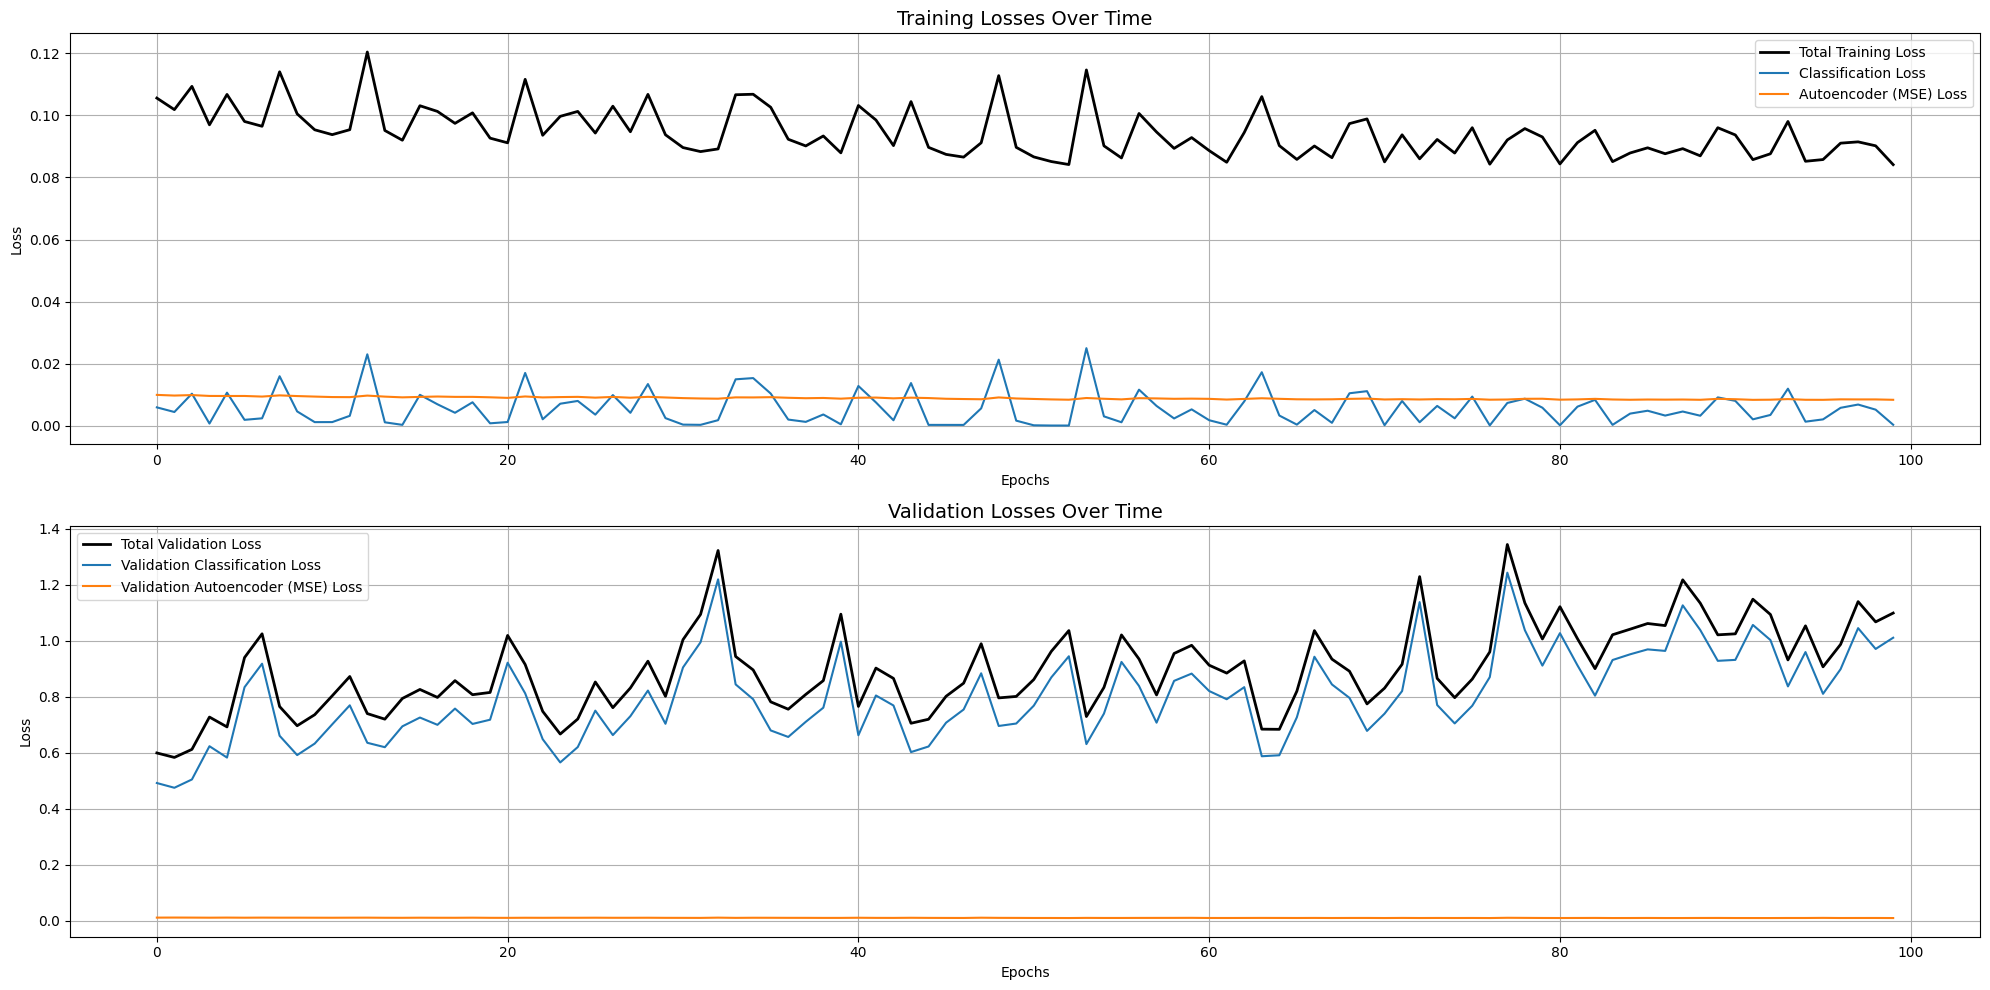

In [17]:
# Create the figure canvas
fig = plt.figure(figsize=[20, 10])

# ==========================================
# TOP GRAPH: Training Losses
# ==========================================
ax = fig.add_subplot(2, 1, 1)

# Plot the combined total loss
ax.plot(history.history['loss'], label='Total Training Loss', color='black', linewidth=2)

# Plot the individual branch losses
# Note the updated keys: <layer_name>_loss
ax.plot(history.history['class_output_loss'], label='Classification Loss')
ax.plot(history.history['decoder_output_loss'], label='Autoencoder (MSE) Loss')

ax.set_title('Training Losses Over Time', fontsize=14)
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True)

# ==========================================
# BOTTOM GRAPH: Validation Losses
# ==========================================
ax = fig.add_subplot(2, 1, 2)

# Plot the combined total validation loss
ax.plot(history.history['val_loss'], label='Total Validation Loss', color='black', linewidth=2)

# Plot the individual branch validation losses
ax.plot(history.history['val_class_output_loss'], label='Validation Classification Loss')
ax.plot(history.history['val_decoder_output_loss'], label='Validation Autoencoder (MSE) Loss')

ax.set_title('Validation Losses Over Time', fontsize=14)
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True)

# Ensure titles and labels don't overlap
plt.tight_layout()
plt.show()

In [9]:


inputs = keras.Input(shape=(28, 28, 1), name='image_input')

# ==========================================
# 1. ENCODER (Upgraded with Batch Norm)
# ==========================================
x = layers.Conv2D(16, (3, 3), padding='same')(inputs)
x = layers.BatchNormalization()(x) # <--- ADDED STABILIZER
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Conv2D(32, (3, 3), padding='same')(x)
x = layers.BatchNormalization()(x) # <--- ADDED STABILIZER
x = layers.Activation('relu')(x)
shared_bottleneck = layers.MaxPooling2D((2, 2), padding='same')(x)

# ==========================================
# 2. CLASSIFIER (Upgraded with Dropout)
# ==========================================
classifier = layers.Flatten()(shared_bottleneck)
classifier = layers.Dense(64, activation='relu')(classifier)

# <--- ADDED DROPOUT (Randomly turns off 50% of connections to stop memorization) --->
classifier = layers.Dropout(0.5)(classifier) 

class_output = layers.Dense(11, activation='softmax', name='class_output')(classifier)

# ==========================================
# 3. DECODER (Upgraded with Batch Norm)
# ==========================================
decoder = layers.Conv2D(32, (3, 3), padding='same')(shared_bottleneck)
decoder = layers.BatchNormalization()(decoder) # <--- ADDED STABILIZER
decoder = layers.Activation('relu')(decoder)
decoder = layers.UpSampling2D((2, 2))(decoder)

decoder = layers.Conv2D(16, (3, 3), padding='same')(decoder)
decoder = layers.BatchNormalization()(decoder) # <--- ADDED STABILIZER
decoder = layers.Activation('relu')(decoder)
decoder = layers.UpSampling2D((2, 2))(decoder)

decoder_output = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same', name='decoder_output')(decoder)

# ==========================================
# BUILD
# ==========================================
multitask_cnn = Model(inputs=inputs, outputs=[class_output, decoder_output])

In [10]:
multitask_cnn.compile(
    optimizer='adam',
    loss={
        'class_output': 'sparse_categorical_crossentropy', 
        'decoder_output': 'mse'                            
    },
    # Force the model to pay 10x more attention to the drawing task
    loss_weights={
        'class_output': 1.0, 
        'decoder_output': 10.0  
    },
    metrics={'class_output': 'accuracy'}
)

In [20]:
history = multitask_cnn.fit(
    x=x_train_reshaped,                                 
    y=[y_train_labels, x_train_reshaped],               # [Target Labels, Target Images]
    batch_size=32,
    epochs=100,
    validation_data=(
        x_val_reshaped,                                 
        [y_val_labels, x_val_reshaped]                  
    ),
    verbose=True
)

Epoch 1/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - class_output_accuracy: 0.5647 - class_output_loss: 1.2268 - decoder_output_loss: 0.0207 - loss: 1.4345 - val_class_output_accuracy: 0.6237 - val_class_output_loss: 1.3369 - val_decoder_output_loss: 0.0231 - val_loss: 1.5679
Epoch 2/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step - class_output_accuracy: 0.7214 - class_output_loss: 0.7739 - decoder_output_loss: 0.0155 - loss: 0.9289 - val_class_output_accuracy: 0.9268 - val_class_output_loss: 0.2545 - val_decoder_output_loss: 0.0155 - val_loss: 0.4106
Epoch 3/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - class_output_accuracy: 0.7651 - class_output_loss: 0.6328 - decoder_output_loss: 0.0142 - loss: 0.7751 - val_class_output_accuracy: 0.9247 - val_class_output_loss: 0.2665 - val_decoder_output_loss: 0.0145 - val_loss: 0.4123
Epoch 4/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - class_output_accuracy: 0.7899 - class_output_loss: 0.5643 - decoder_output_loss: 0.0136 - loss: 0.70

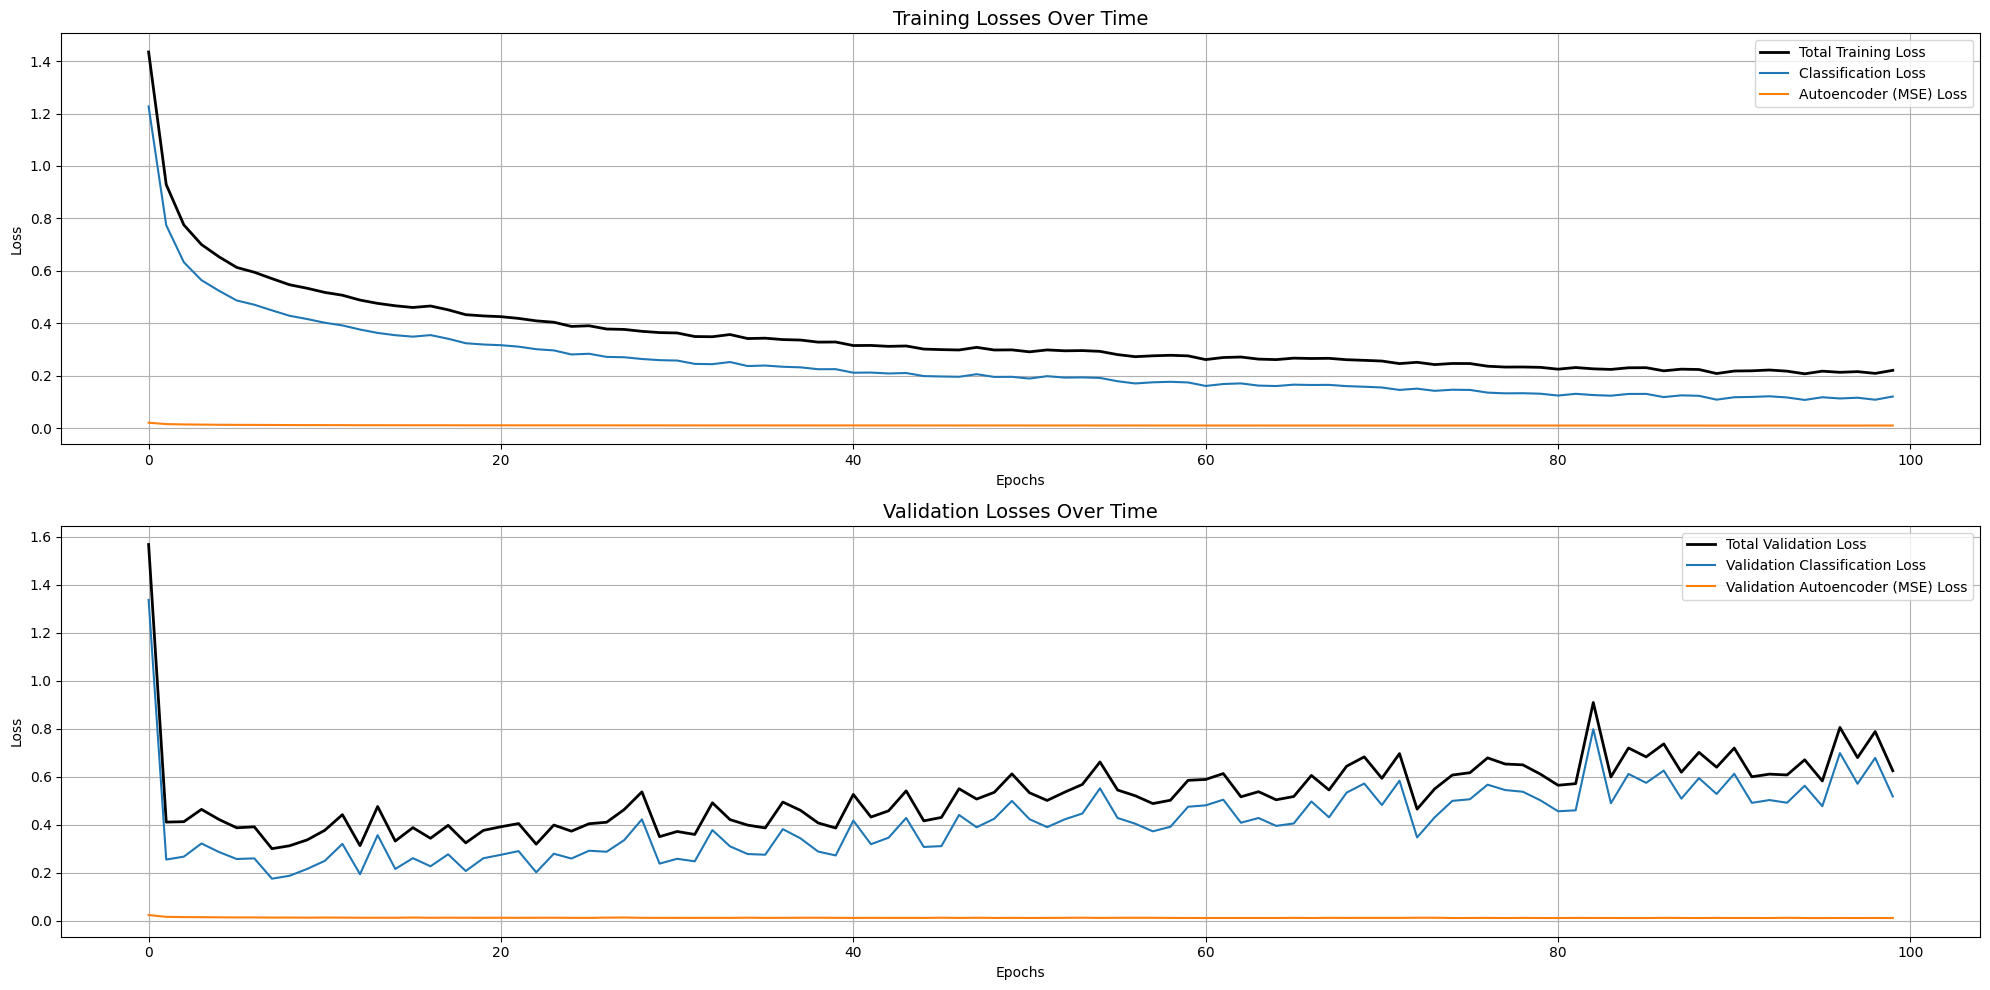

In [21]:
# Create the figure canvas
fig = plt.figure(figsize=[20, 10])

# ==========================================
# TOP GRAPH: Training Losses
# ==========================================
ax = fig.add_subplot(2, 1, 1)

# Plot the combined total loss
ax.plot(history.history['loss'], label='Total Training Loss', color='black', linewidth=2)

# Plot the individual branch losses
# Note the updated keys: <layer_name>_loss
ax.plot(history.history['class_output_loss'], label='Classification Loss')
ax.plot(history.history['decoder_output_loss'], label='Autoencoder (MSE) Loss')

ax.set_title('Training Losses Over Time', fontsize=14)
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True)

# ==========================================
# BOTTOM GRAPH: Validation Losses
# ==========================================
ax = fig.add_subplot(2, 1, 2)

# Plot the combined total validation loss
ax.plot(history.history['val_loss'], label='Total Validation Loss', color='black', linewidth=2)

# Plot the individual branch validation losses
ax.plot(history.history['val_class_output_loss'], label='Validation Classification Loss')
ax.plot(history.history['val_decoder_output_loss'], label='Validation Autoencoder (MSE) Loss')

ax.set_title('Validation Losses Over Time', fontsize=14)
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True)

# Ensure titles and labels don't overlap
plt.tight_layout()
plt.show()

In [18]:
from tensorflow.keras.optimizers import Adam

y_train_labels = train_dataset.labels
y_val_labels = val_dataset.labels
 
# 1. Define the custom optimizer (slowing down the learning rate)
custom_adam = Adam(learning_rate=0.0001)

# 2. Compile the model using the optimizer and our aggressive loss weights
multitask_cnn.compile(
    optimizer=custom_adam,  
    loss={
        'class_output': 'sparse_categorical_crossentropy', 
        'decoder_output': 'mse'                            
    },
    loss_weights={
        'class_output': 1.0, 
        'decoder_output': 50.0  # Forcing the network to care about drawing!
    },
    metrics={'class_output': 'accuracy'}
)

print("Model compiled successfully with custom learning rate and loss weights!")

from tensorflow.keras.callbacks import EarlyStopping

# Create the Early Stopping rule
# 'patience=10' means: if the validation loss doesn't improve for 10 epochs, stop.
# 'restore_best_weights=True' means: give me the model from the best epoch, not the last one.
early_stopper = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True,
    verbose=1
)

# Pass it into your fit function using the 'callbacks' list
history = multitask_cnn.fit(
    x=x_train_reshaped,                                 
    y=[y_train_labels, x_train_reshaped],               
    batch_size=32,
    epochs=100, # You can leave this at 100, EarlyStopping will cut it off early!
    validation_data=(x_val_reshaped, [y_val_labels, x_val_reshaped]),
    callbacks=[early_stopper], 
    verbose=True
)

Model compiled successfully with custom learning rate and loss weights!
Epoch 1/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 28s 61ms/step - class_output_accuracy: 0.6951 - class_output_loss: 0.9537 - decoder_output_loss: 0.0210 - loss: 2.0062 - val_class_output_accuracy: 0.9147 - val_class_output_loss: 0.3569 - val_decoder_output_loss: 0.0197 - val_loss: 1.3439
Epoch 2/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 25s 61ms/step - class_output_accuracy: 0.7470 - class_output_loss: 0.7759 - decoder_output_loss: 0.0181 - loss: 1.6803 - val_class_output_accuracy: 0.9239 - val_class_output_loss: 0.2861 - val_decoder_output_loss: 0.0178 - val_loss: 1.1755
Epoch 3/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 30s 73ms/step - class_output_accuracy: 0.7850 - class_output_loss: 0.6740 - decoder_output_loss: 0.0168 - loss: 1.5112 - val_class_output_accuracy: 0.9352 - val_class_output_loss: 0.2479 - val_decoder_output_loss: 0.0167 - val_loss: 1.0837
Epoch 4/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 28s 68ms/step - class_output_accuracy: 0.812

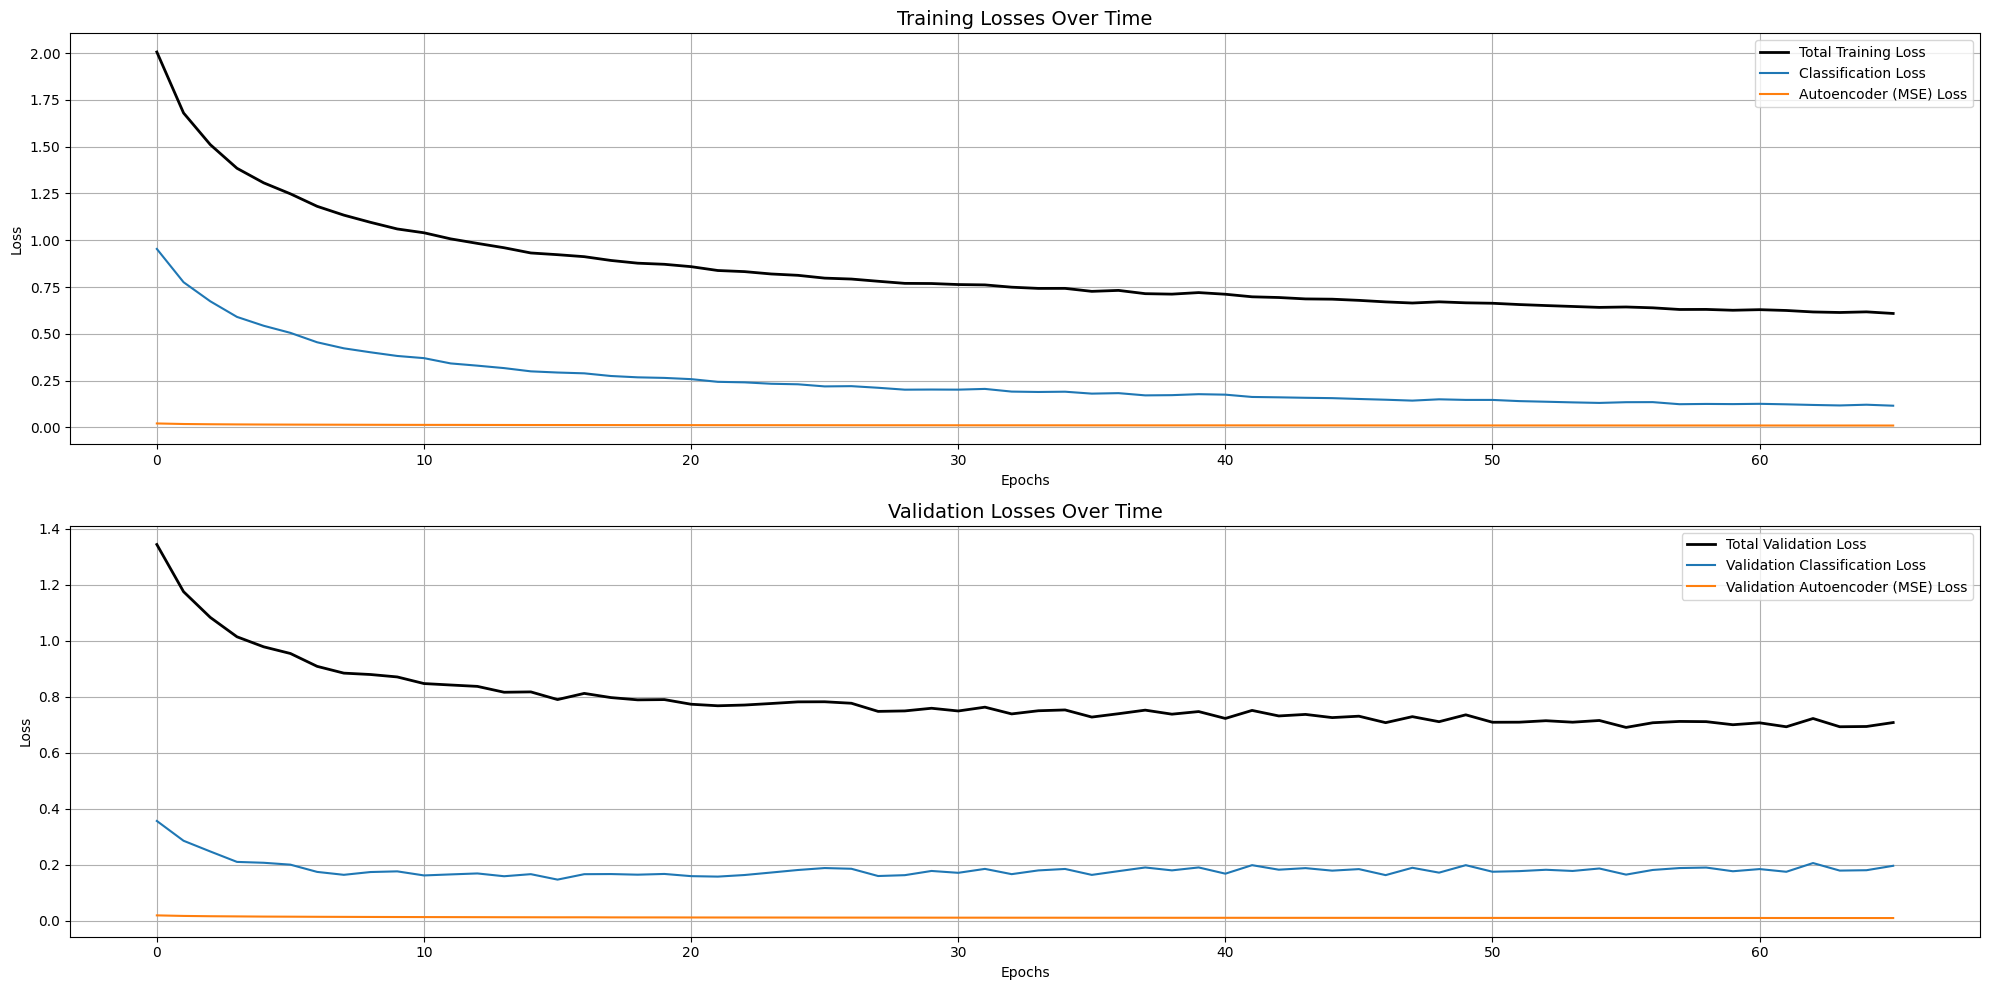

In [19]:
# Create the figure canvas
fig = plt.figure(figsize=[20, 10])

# ==========================================
# TOP GRAPH: Training Losses
# ==========================================
ax = fig.add_subplot(2, 1, 1)

# Plot the combined total loss
ax.plot(history.history['loss'], label='Total Training Loss', color='black', linewidth=2)

# Plot the individual branch losses
# Note the updated keys: <layer_name>_loss
ax.plot(history.history['class_output_loss'], label='Classification Loss')
ax.plot(history.history['decoder_output_loss'], label='Autoencoder (MSE) Loss')

ax.set_title('Training Losses Over Time', fontsize=14)
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True)

# ==========================================
# BOTTOM GRAPH: Validation Losses
# ==========================================
ax = fig.add_subplot(2, 1, 2)

# Plot the combined total validation loss
ax.plot(history.history['val_loss'], label='Total Validation Loss', color='black', linewidth=2)

# Plot the individual branch validation losses
ax.plot(history.history['val_class_output_loss'], label='Validation Classification Loss')
ax.plot(history.history['val_decoder_output_loss'], label='Validation Autoencoder (MSE) Loss')

ax.set_title('Validation Losses Over Time', fontsize=14)
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True)

# Ensure titles and labels don't overlap
plt.tight_layout()
plt.show()

We have achieved model stability (smooth ish curves). 

257/257 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step


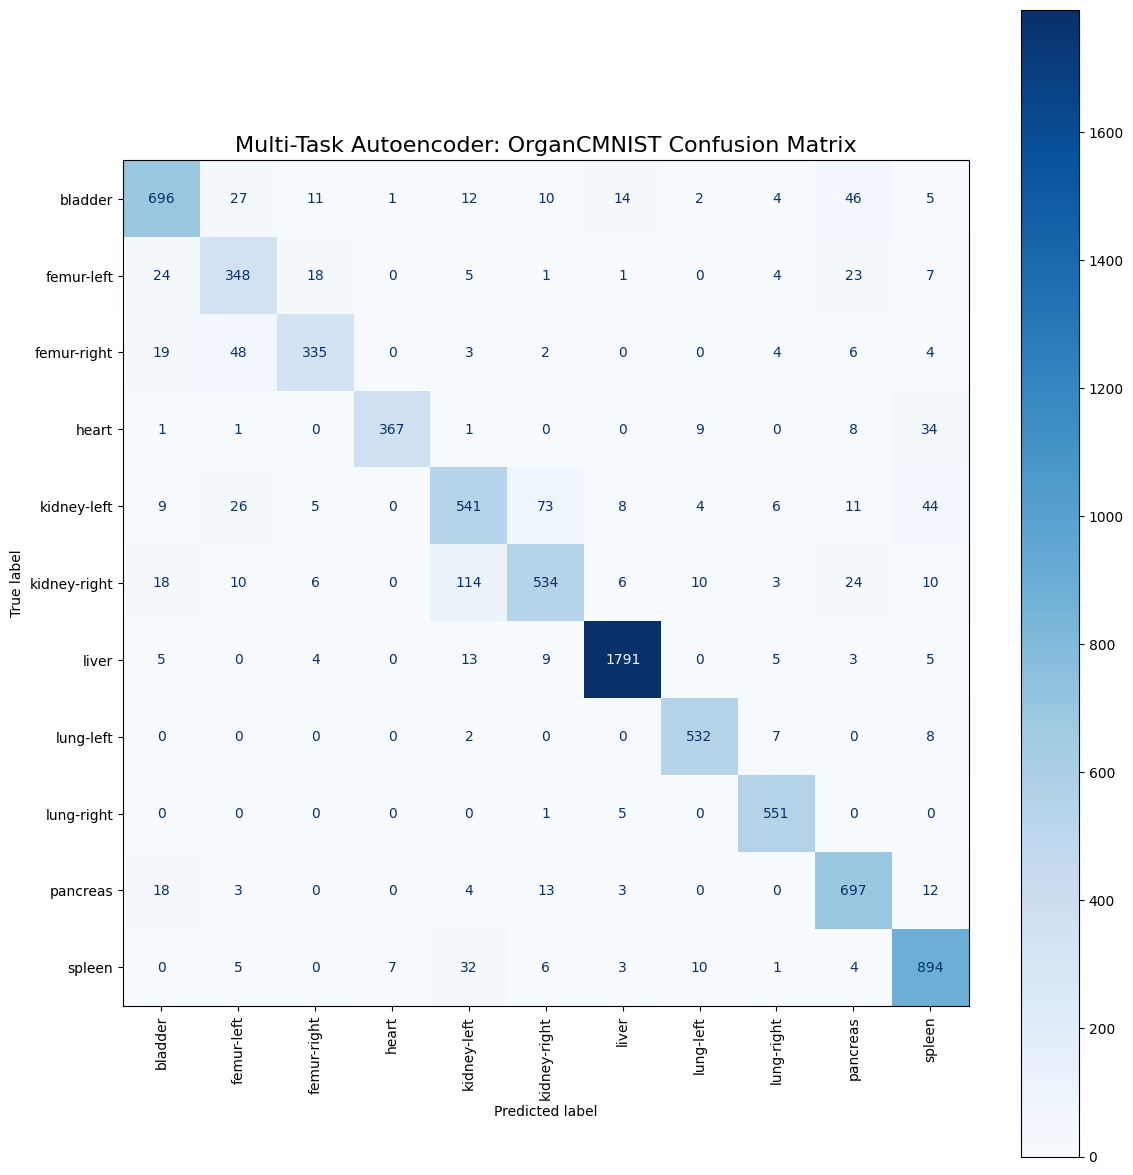

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Generate the predictions
predictions, decoded_imgs = multitask_cnn.predict(x_test_reshaped)
indexes = np.argmax(predictions, axis=1)

# 2. Extract and format the ground truth labels
y_test_labels = test_dataset.labels
gt = y_test_labels.flatten()

# 3. Define the actual OrganCMNIST class names 
organ_classes = [
    "bladder", "femur-left", "femur-right", "heart", "kidney-left", 
    "kidney-right", "liver", "lung-left", "lung-right", "pancreas", "spleen"
]

# 4. Build and Plot the Confusion Matrix
cm = confusion_matrix(gt, indexes)

fig = plt.figure(figsize=[12, 12])
ax = fig.add_subplot(1, 1, 1)

c = ConfusionMatrixDisplay(cm, display_labels=organ_classes)
c.plot(ax=ax, cmap='Blues', xticks_rotation='vertical')

plt.title('Multi-Task Autoencoder: OrganCMNIST Confusion Matrix', fontsize=16)
plt.tight_layout()
plt.show()

The model had trouble classifying the left from the right kidney (which is expected) why??

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Running t-SNE on Training Data (this might take a minute)...


/Users/jessie.bowness/venvs/cab420_venv/lib/python3.12/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Running t-SNE on Testing Data...


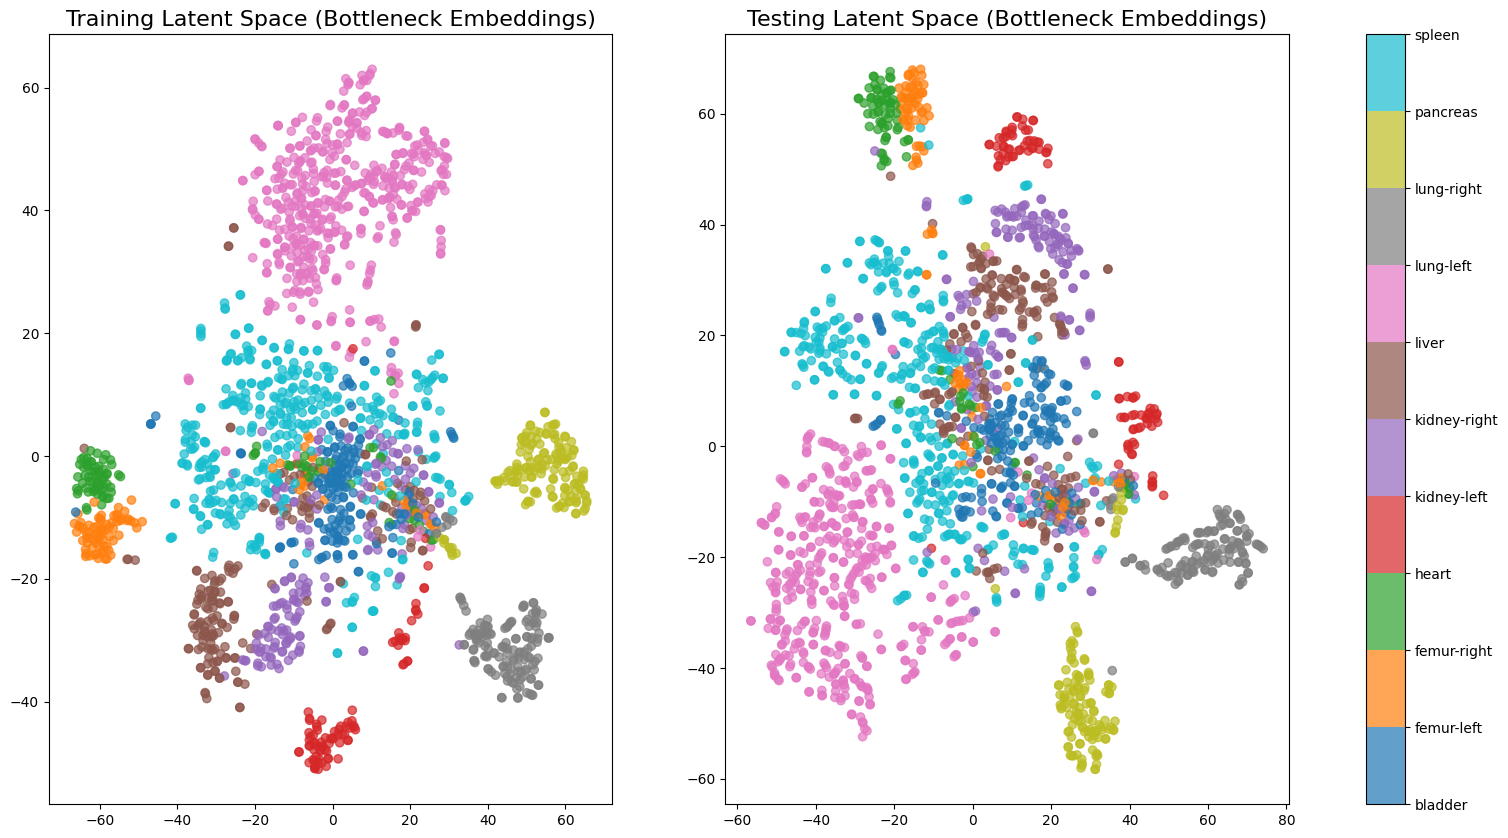

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from tensorflow.keras.models import Model

# 1. Extract the shared bottleneck layer using the exact name from your summary
bottleneck_output = multitask_cnn.get_layer('max_pooling2d_3').output 
bottleneck_model = Model(inputs=multitask_cnn.input, outputs=bottleneck_output)

# 2. Slice the data so your laptop doesn't crash (first 2000 images)
sample_train_imgs = x_train_reshaped[:2000]
sample_train_labels = y_train_labels[:2000].flatten()

sample_test_imgs = x_test_reshaped[:2000]
sample_test_labels = y_test_labels[:2000].flatten()

# 3. Generate the bottleneck embeddings and flatten them automatically
# The '-1' dynamically calculates the 1568 flattened dimensions
train_embeddings = np.reshape(bottleneck_model.predict(sample_train_imgs), (len(sample_train_imgs), -1))
test_embeddings = np.reshape(bottleneck_model.predict(sample_test_imgs), (len(sample_test_imgs), -1))

# 4. Run t-SNE to squash the 1568 dimensions down to 2 dimensions for plotting
print("Running t-SNE on Training Data (this might take a minute)...")
tsne_train = TSNE(random_state=4).fit_transform(train_embeddings)

print("Running t-SNE on Testing Data...")
tsne_test = TSNE(random_state=4).fit_transform(test_embeddings)

# 5. Define the actual OrganCMNIST class names for the legend
organ_classes = [
    "bladder", "femur-left", "femur-right", "heart", "kidney-left", 
    "kidney-right", "liver", "lung-left", "lung-right", "pancreas", "spleen"
]

# 6. Plot the results!
fig = plt.figure(figsize=[20, 10])

# Training Plot
ax1 = fig.add_subplot(1, 2, 1)
scatter1 = ax1.scatter(tsne_train[:, 0], tsne_train[:, 1], c=sample_train_labels, cmap='tab10', alpha=0.7)
ax1.set_title('Training Latent Space (Bottleneck Embeddings)', fontsize=16)

# Testing Plot
ax2 = fig.add_subplot(1, 2, 2)
scatter2 = ax2.scatter(tsne_test[:, 0], tsne_test[:, 1], c=sample_test_labels, cmap='tab10', alpha=0.7)
ax2.set_title('Testing Latent Space (Bottleneck Embeddings)', fontsize=16)

# Add a colorbar legend to show which color is which class
cbar = plt.colorbar(scatter2, ax=[ax1, ax2], ticks=range(11))
cbar.ax.set_yticklabels(organ_classes)

plt.show()

A constraint of the dataset is that while it is easy to tell which organ from which from a full ct scan, the dataset crops the image down to just the organ itself, all global positional data is destroyed
Grouping of left and right kidney overlaps because they just looks the exact same, just mirorred version of each others. 

The network uses MSE to reconstruct the image. he MSE loss forces the encoder to group images together if they look the same physically. Because a cropped left kidney and right kidney share the exact same physical shape, texture, and pixel intensity, the Autoencoder mathematically forces their embeddings together in the latent spac

In [27]:
from sklearn.metrics import f1_score, classification_report

# 1. Calculate the specific F1 scores
macro_f1 = f1_score(gt, indexes, average='macro')
weighted_f1 = f1_score(gt, indexes, average='weighted')

# Print them formatted to 4 decimal places
print(f"Macro F1 Score:    {macro_f1:.4f}")
print(f"Weighted F1 Score: {weighted_f1:.4f}")
print("-" * 50)

# 2. Generate a comprehensive report for all 11 classes
report = classification_report(gt, indexes, target_names=organ_classes)
print("Detailed Classification Report:\n")
print(report)

Macro F1 Score:    0.8721
Weighted F1 Score: 0.8861
--------------------------------------------------
Detailed Classification Report:

              precision    recall  f1-score   support

     bladder       0.88      0.84      0.86       828
  femur-left       0.74      0.81      0.77       431
 femur-right       0.88      0.80      0.84       421
       heart       0.98      0.87      0.92       421
 kidney-left       0.74      0.74      0.74       727
kidney-right       0.82      0.73      0.77       735
       liver       0.98      0.98      0.98      1835
   lung-left       0.94      0.97      0.95       549
  lung-right       0.94      0.99      0.96       557
    pancreas       0.85      0.93      0.89       750
      spleen       0.87      0.93      0.90       962

    accuracy                           0.89      8216
   macro avg       0.88      0.87      0.87      8216
weighted avg       0.89      0.89      0.89      8216

